# Okinawa Forams image analysis pipeline

This notebook is a demonstration of how the qim3d library can be utilized in a classic image analysis pipeline of [Okinawa Forams](https://data.qim.dk/pages/okinawa_forams.html).

## Imports

In [1]:
import os

import qim3d
import qim3d.io
import qim3d.viz
import qim3d.segmentation

import numpy as np
import matplotlib.pyplot as plt

from skimage.morphology import closing, ball
from skimage.filters import threshold_otsu

## Downloading and downsampling data

The QIM Center provides a repository of 3D datasets available at https://data.qim.dk/

qim3d provides an interface for downloading files from the repository.

In [2]:
downloader = qim3d.io.Downloader()

Running `downloader.list_files()` will among others show the following information about the dataset of interest:

```markdown
╭────────────────╮
│ Okinawa_Forams │
╰────────────────╯
Okinawa_Forams.Okinawa_Foram_1                    (1.85GB)
Okinawa_Forams.Okinawa_Foram_2                    (1.84GB)
```

The following block will save the datasets under the folder `Okinawa_Forams`.

In [3]:
dataset = 'Okinawa_Forams'
paths = {}
for i in [1, 2]:
    base = f'Okinawa_Foram_{i}'
    paths[i] = os.path.join(dataset, base + '.tif')
    getattr(getattr(downloader, dataset), base)(load_file=False)

https://archive.compute.dtu.dk/download/public/projects/viscomp_data_repository/Okinawa_Forams/Okinawa_Foram_1.tif

https://archive.compute.dtu.dk/download/public/projects/viscomp_data_repository/Okinawa_Forams/Okinawa_Foram_2.tif

.84GB [00:17, 113MB/s]                                                         

Here we use a downsampled version of the dataset to make the pipeline able to run on most computers without too much processing time. One could use the whole dataset instead if appropriate modifications are done in the pipeline. Same goes for the dataset: we show the analysis for the first dataset but the pipeline could also be applied to the second dataset.

In [4]:
data_id = 1
use_downsampled = True

if use_downsampled:
    downsampled_path = os.path.join(dataset, f'foram{data_id}_downsampled.tif')
    if not os.path.exists(downsampled_path):
        vol = qim3d.io.load(paths[data_id])
        print(f"Original shape: {vol.shape}")
        
        vol_downsampled = vol[::3, ::3, ::3]
        
        qim3d.io.save(downsampled_path, vol_downsampled)
        print(f"Downsampled shape: {vol_downsampled.shape}")
        print(f"Saved downsampled volume to {downsampled_path}")
    
    vol = qim3d.io.load(downsampled_path)
else:
    vol = qim3d.io.load(os.path.join(dataset, f'Okinawa_Foram_{data_id}'))

Original shape: (995, 1014, 984)
Downsampled shape: (332, 338, 328)
Saved downsampled volume to Okinawa_Forams/foram1_downsampled.tif


## Data exploration

In [5]:
print(f'Data type: {vol.dtype}')
print(f'Data range: [{vol.min()}, {vol.max()}]')

Data type: uint16
Data range: [0, 63702]


We start out by converting the volume to float datatype and normalizing to the unit range to prepare for performing numerical operations and for easier comparisons later on.

In [6]:
vol = (lambda x: (x-x.min())/(x.max()-x.min()))(vol.astype(np.float32))

In [7]:
qim3d.viz.slicer_orthogonal(vol)

The goal will be to calculate the number of inner cavities and their volumes.

From the visual exploration, we observe the following issues:
- A spongy pattern with small, shallow holes and openings that are not quite big enough to be classified as inner cavities.
- Some cavities have ruptured walls leading to openings either to the outside background or connecting adjacent inner cavities.

To address these issues, we will apply morphological closing in order to:
- Seal the small gaps that should not be counted as inner cavities
- Repair broken cavity walls.

## Image processing

In [8]:
vol_closed = closing(vol, footprint=ball(radius=3))
qim3d.viz.compare_volumes(vol, vol_closed)

The spongy pattern is essentially gone now, which makes the segmentation easier.

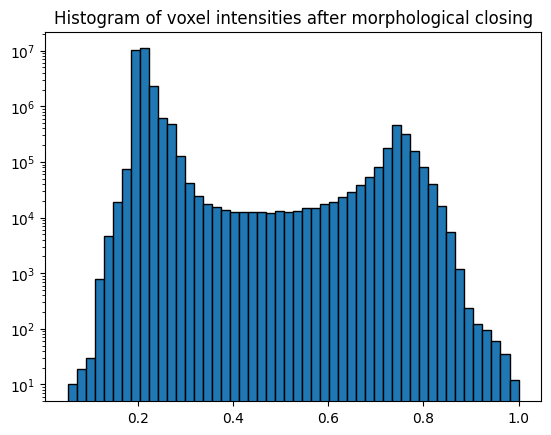

In [9]:
plt.hist(vol_closed[vol_closed > 0].ravel(), bins=50, edgecolor='black')
plt.yscale('log')
plt.title('Histogram of voxel intensities after morphological closing')
plt.show()

The histograms show that there is a clear binary separation between the two classes. To automate the threshold, we use Otsu's method.

In [10]:
thres = threshold_otsu(vol_closed)
vol_binary = vol_closed < thres
qim3d.viz.compare_volumes(vol_closed, vol_binary)

In [11]:
qim3d.viz.slicer_orthogonal(vol_binary)

## Connected components

Now we separate the cavities using connected component labeling. Since the background is also a component with clearly the largest volume, we use this criteria to filter it out.

In [12]:
cc = qim3d.segmentation.get_3d_cc(vol_binary)

Total number of connected components found: 54


In [13]:
labels = cc.get_cc()

In [14]:
volumes = np.array([np.sum(labels == i).item() for i in range(cc.cc_count+1)])

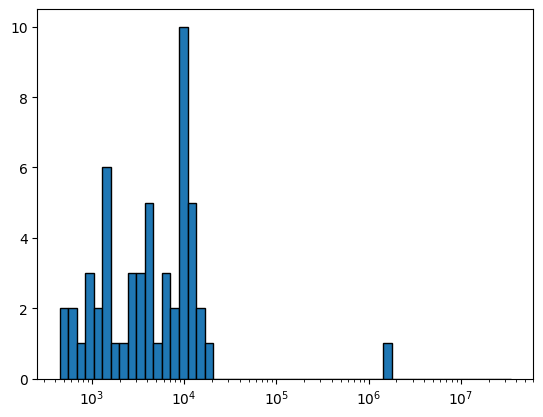

In [15]:
bins = np.logspace(np.log10(volumes.min()), np.log10(volumes.max()), cc.cc_count)
plt.hist(volumes, bins=bins, edgecolor='black')
plt.xscale('log')
plt.show()

Here remove the background component.

In [16]:
background_index = np.argmax(volumes[1:]) + 1
labels[labels == background_index] = 0

Now we can show the extracted components.

In [17]:
qim3d.viz.slicer_orthogonal(labels, color_map='segmentation')

The following 3D rendering might take some time but is a great way to see the different inner cavities and how they spatially relate to each other.

In [22]:
cmap_bright = qim3d.viz.colormaps.segmentation(num_labels=cc.cc_count+1, style = 'bright', first_color_background=True, background_color="black", min_dist=0.7)
qim3d.viz.volumetric(labels, color_map=cmap_bright, opacity_function="constant")

Output()

In the following we compare our segmentation with the original volume. We see that most of the inner cavities match quite well with the exception of a few.

In [19]:
qim3d.viz.compare_volumes(vol, labels > 0)

## Inner cavity quantification

To wrap off we show our estimate of the number of cavities and the distribution of their volumes.

In [20]:
number_of_inner_cavities = cc.cc_count-1
print(f'{number_of_inner_cavities=}')

number_of_inner_cavities=53


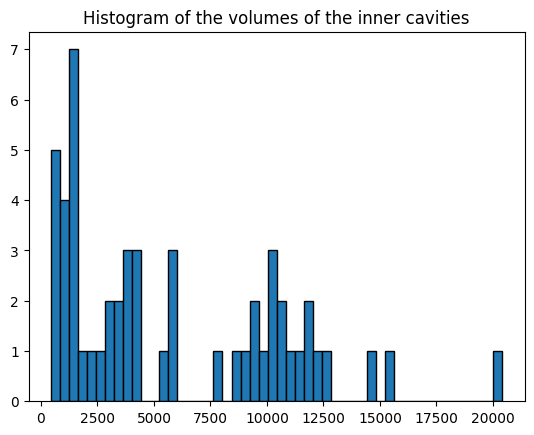

In [21]:
inner_cavity_volumes = np.delete(volumes, [0,background_index])
plt.hist(inner_cavity_volumes, bins=50, edgecolor='black')
plt.title('Histogram of the volumes of the inner cavities')
plt.show()